# Signed Integral Distance

For a signed measure $\sigma$, write its cumulative lower-set function as
$H_\sigma(x)=\sigma(\{u:u\le x\})$. Unlike `integral_distance`, which
integrates an absolute value pointwise, `signed_integral_distance` first keeps
the sign of the difference and then takes one absolute value at the end:

$$
d_{\pm}(\mu,\nu)=\left|\int_B \bigl(F_\mu(x)-F_\nu(x)\bigr)\,dx\right|.
$$

This can cancel positive and negative regions. With `absolute=False`, the
function returns the signed integral before the final absolute value.

In [1]:
import numpy as np
import multipers as mp
import matplotlib.pylab as plt
from multipers.data import noisy_annulus
from multipers.distances import signed_integral_distance

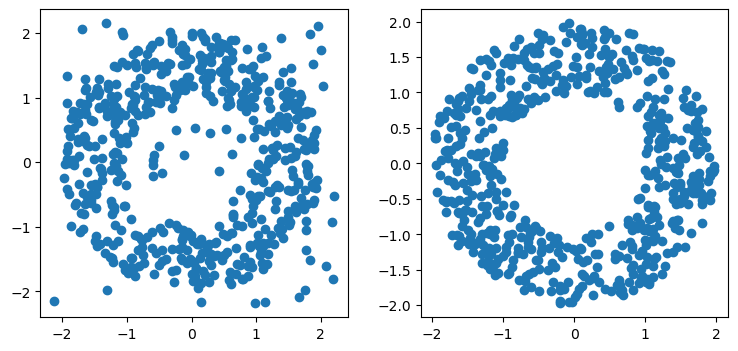

In [2]:
# Point clouds first. Same pipeline as the integral-distance notebook, different
# noise profile.
X = noisy_annulus(500, 100)
Y = noisy_annulus(600, 0)

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
a.scatter(*X.T)
a.set_aspect(1)

b.scatter(*Y.T)
b.set_aspect(1)
plt.show()

Build the same Delaunay-codensity filtrations and degree-1
[minimal presentations](../ops/minimal_presentations_resolutions.ipynb) as in
the integral-distance notebook. See the
[Delaunay Lowerstar filtrations](../filtrations/function_delaunay.ipynb)
notebook for construction details.

In [3]:
f1 = mp.filtrations.DelaunayCodensity(points=X, bandwidth=0.1, reduce_degree=1).minpres(
    1,
    full_resolution=1,
)
f2 = mp.filtrations.DelaunayCodensity(points=Y, bandwidth=0.1, reduce_degree=1).minpres(
    1,
    full_resolution=1,
)

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


The [Hilbert signed measure](../invariants/signed_measure.ipynb) is the sparse
Möbius inversion whose cumulative lower-set sum is the
[Hilbert function](../invariants/hilbert_function.ipynb). The signed integral
keeps the sign of $H_{\mu}-H_{\nu}$ across the whole box, so positive and
negative regions can cancel before the final absolute value.

/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/plots.py:189: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/plots.py:189: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


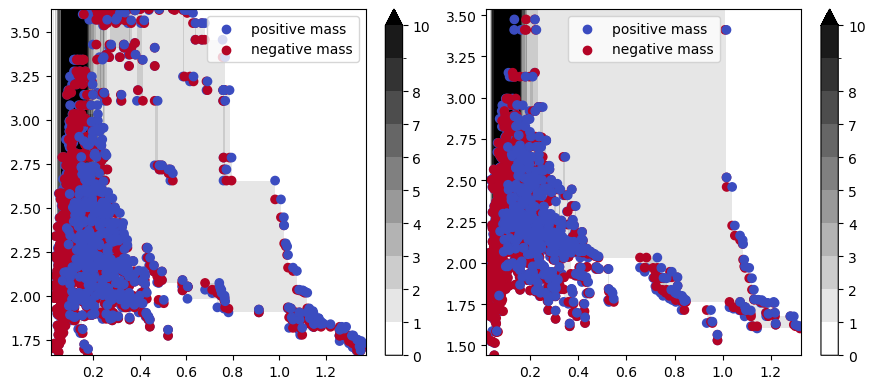

In [7]:

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
plt.sca(a)
mp.invariants.hilbert_function(f1, plot=True)
sm1, =mp.signed_measure(f1, invariant="hilbert", plot=True)
plt.sca(b)
mp.invariants.hilbert_function(f2, plot=True)
sm2, = mp.signed_measure(f2, invariant="hilbert", plot=True)
plt.show()

To see the sign, sample both Hilbert functions on a common grid and plot the
signed difference $H_{\mu}-H_{\nu}$. The Riemann sum below approximates

$$
\int_B \bigl(H_{\mu}(x)-H_{\nu}(x)\bigr)\,dx.
$$

Unlike `integral_distance`, there is no pointwise absolute value here.

np.float64(-0.9361205829959491)

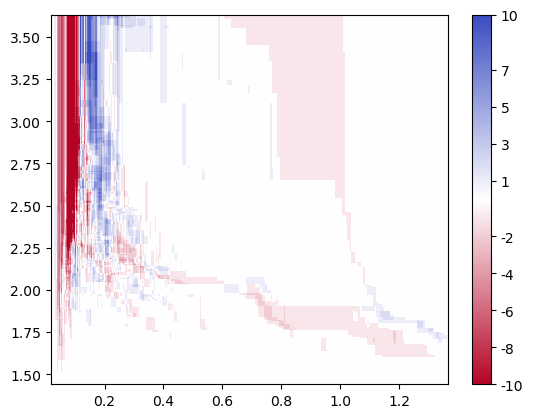

In [8]:
plt.figure()
grid = mp.grids.compute_grid_from_iterable((f1, f2), resolution=1000, strategy="regular")
h1 = mp.invariants.hilbert_function(f1, grid=grid)
h2 = mp.invariants.hilbert_function(f2, grid=grid)
mp.plots.plot_surface(grid, h1 - h2)
cell_volume = np.prod([np.asarray(axis)[1] - np.asarray(axis)[0] for axis in grid])
signed_riemann_sum = (h1 - h2).sum() * cell_volume
signed_riemann_sum

In [9]:
signed_integral_distance(
    sm1,
    sm2,
    invariant="hilbert",
    absolute=False,
)

np.float64(-0.9383138992702698)